In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import shap
import tensorflow as tf

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = r'C:\Users\sharif\Desktop\6.9-Final_AllReactive.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""ETHANOL"").T","STREAMS(""P-ACID"").T","STREAMS(""S15"").T","STREAMS(""C1-INPUT"").T","STREAMS(""S26"").T","STREAMS(""S28"").T","STREAMS(""ETHANOL"").P","STREAMS(""P-ACID"").P","STREAMS(""S15"").P","STREAMS(""C1-INPUT"").P",...,"BLOCKS(""C1"").Stage(29).T","BLOCKS(""C1"").Stage(30).T","BLOCKS(""C1"").Stage(31).T","BLOCKS(""C1"").Stage(32).T","BLOCKS(""C1"").Stage(33).T","STREAMS(""D1"").Zmn(""ETHYL-01"")","STREAMS(""S29"").Zmn(""ETHYL-01"")","STREAMS(""S8"").Zmn(""ETHYL-01"")","STREAMS(""S29"").F","STREAMS(""D1"").F"
0,25.0,25.0,146.692,139.972,25.4830,25.3346,1.01325,1.01325,1.20551,1.20551,...,141.881,142.038,142.194,142.349,142.584,0.933737,0.999927,0.740045,49.0159,287.386
1,25.0,25.0,146.693,139.972,25.4839,25.3356,1.01325,1.01325,1.20552,1.20552,...,141.883,142.039,142.195,142.351,142.585,0.933735,0.999927,0.740045,49.0159,287.387
2,25.0,25.0,146.693,139.972,25.4844,25.3361,1.01325,1.01325,1.20552,1.20552,...,141.884,142.040,142.196,142.352,142.586,0.933733,0.999927,0.740045,49.0159,287.387
3,25.0,25.0,146.693,139.972,25.4846,25.3363,1.01325,1.01325,1.20552,1.20552,...,141.884,142.041,142.197,142.352,142.586,0.933731,0.999927,0.740045,49.0160,287.387
4,25.0,25.0,146.693,139.972,25.4848,25.3365,1.01325,1.01325,1.20553,1.20553,...,141.885,142.041,142.197,142.352,142.586,0.933730,0.999927,0.740045,49.0160,287.387


In [3]:
data = df.values
X_raw = data[:, :-5]  
Y_raw = data[:, -5:] 

In [4]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
X_scaled = x_scaler.fit_transform(X_raw)
Y_scaled = y_scaler.fit_transform(Y_raw)

In [5]:
def create_sequences(X, Y, time_steps=10):
    Xs, Ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        Ys.append(Y[i + time_steps])
    return np.array(Xs), np.array(Ys)

In [6]:
time_steps = 10
X_seq, Y_seq = create_sequences(X_scaled, Y_scaled, time_steps)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, Y_seq, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [8]:
inputs = Input(shape=(time_steps, X_seq.shape[2]))
lstm_out = LSTM(128, return_sequences=True)(inputs)
attention = Attention()([lstm_out, lstm_out])
concat = Concatenate()([lstm_out, attention])
lstm_out2 = LSTM(64)(concat)
dense = Dense(64, activation='relu')(lstm_out2)
output = Dense(5)(dense)

model = Model(inputs, output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 83)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 10, 128)   │    108,544 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 10, 128)   │          0 │ lstm[0][0],       │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10, 256)   │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     82,176 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 195,205 (762.52 KB)

 Trainable params: 195,205 (762.52 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=200,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0393 - mae: 0.1049 - val_loss: 0.0035 - val_mae: 0.0279
Epoch 2/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0038 - mae: 0.0250 - val_loss: 0.0028 - val_mae: 0.0190
Epoch 3/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.0036 - mae: 0.0226 - val_loss: 0.0029 - val_mae: 0.0222
Epoch 4/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0031 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0198
Epoch 5/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 0.0037 - mae: 0.0232 - val_loss: 0.0024 - val_mae: 0.0175
Epoch 6/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0026 - mae: 0.0201 - val_loss: 0.0030 - val_mae: 0.0198
Epoch 7/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 0.0038 - mae: 0.0212 - val_loss: 0.0034 - val_mae: 0.0265
Epoch 8/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 0.0037 - mae: 0.0222 - val_loss: 0.0027 - val_mae: 0.0232
Epoch 9/200
140/140 ━━━━━━━━━━━━━━━━━━━

In [10]:
y_pred = model.predict(X_test)
y_test_inv = y_scaler.inverse_transform(y_test)
y_pred_inv = y_scaler.inverse_transform(y_pred)

for i in range(5):
    print(f"Target {i+1} - R2: {r2_score(y_test_inv[:, i], y_pred_inv[:, i]):.4f}, "
          f"MSE: {mean_squared_error(y_test_inv[:, i], y_pred_inv[:, i]):.4f}, "
          f"MAE: {mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i]):.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Target 1 - R2: 0.9998, MSE: 0.0000, MAE: 0.0000
Target 2 - R2: 0.9780, MSE: 0.0000, MAE: 0.0000
Target 3 - R2: 0.9993, MSE: 0.0000, MAE: 0.0000
Target 4 - R2: 0.9997, MSE: 0.0000, MAE: 0.0045
Target 5 - R2: 0.9998, MSE: 0.0009, MAE: 0.0230


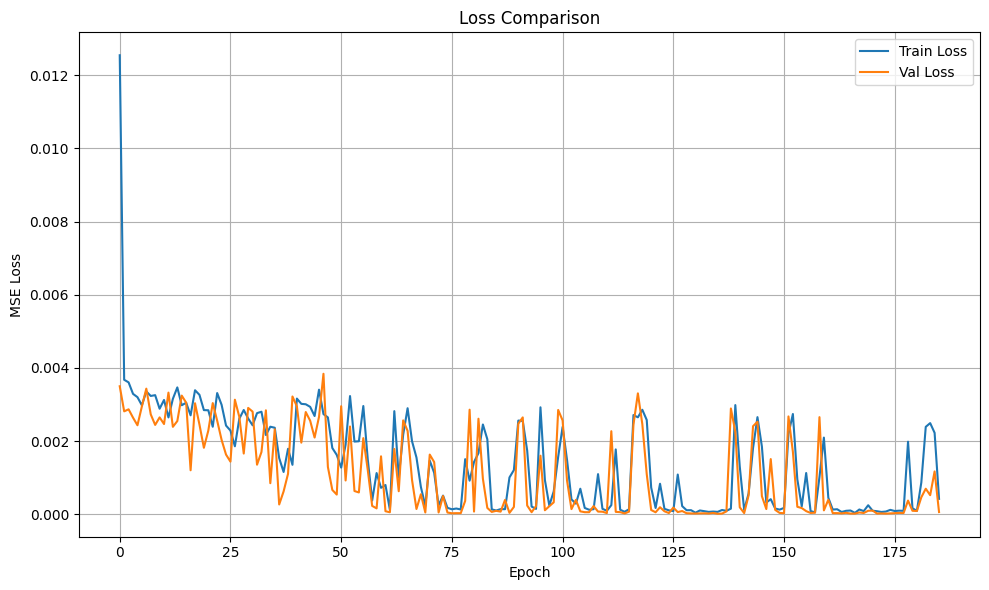

In [11]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
columns = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']
df_results = pd.DataFrame({
    f'Actual {col}': y_test_inv[:, i] for i, col in enumerate(columns)
} | {
    f'Predicted {col}': y_pred_inv[:, i] for i, col in enumerate(columns)
})

print(df_results.head(20))

    Actual Target1  Actual Target2  Actual Target3  Actual Target4  \
0         0.933699        0.999927        0.739942         48.9834   
1         0.934075        0.999927        0.739887         49.3011   
2         0.933711        0.999927        0.740028         49.0062   
3         0.934615        0.999927        0.739341         49.3425   
4         0.933059        0.999927        0.738839         49.0726   
5         0.933628        0.999927        0.739898         48.9871   
6         0.934529        0.999927        0.740236         49.1617   
7         0.931757        0.999927        0.740006         48.4671   
8         0.933627        0.999927        0.741216         48.3568   
9         0.934105        0.999927        0.740111         49.3236   
10        0.933695        0.999927        0.740018         49.0036   
11        0.933684        0.999927        0.739825         49.0390   
12        0.932447        0.999927        0.738473         49.0552   
13        0.931635  

In [13]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [14]:
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # به ترتیب: 3 تا غلظت، 2 تا دبی

# تولرانس‌های جداگانه برای هر خروجی
tolerances_per_output = {
    'Target1': [0.001, 0.0001, 0.00005],  # غلظت
    'Target2': [0.001, 0.0001, 0.00005],  # غلظت
    'Target3': [0.001, 0.0001, 0.00005],  # غلظت
    'Target4': [0.02, 0.05, 0.1],             # دبی
    'Target5': [0.02, 0.05, 0.1]              # دبی
}
all_results = {label: [] for label in labels}

In [15]:
# بررسی دقت بر اساس تولرانس‌های اختصاصی هر خروجی
for label_index, label in enumerate(labels):
    print(f"\n--- Accuracy for {label} ---")
    for tol in tolerances_per_output[label]:
        acc = percentage_within_tolerance(y_test_inv[:, label_index], y_pred_inv[:, label_index], tolerance=tol)
        all_results[label].append(acc)
        print(f"Tolerance ±{tol}: {acc:.2f}%")


--- Accuracy for Target1 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 99.91%

--- Accuracy for Target2 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 100.00%

--- Accuracy for Target3 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 97.50%

--- Accuracy for Target4 ---
Tolerance ±0.02: 99.91%
Tolerance ±0.05: 100.00%
Tolerance ±0.1: 100.00%

--- Accuracy for Target5 ---
Tolerance ±0.02: 53.22%
Tolerance ±0.05: 92.22%
Tolerance ±0.1: 99.55%


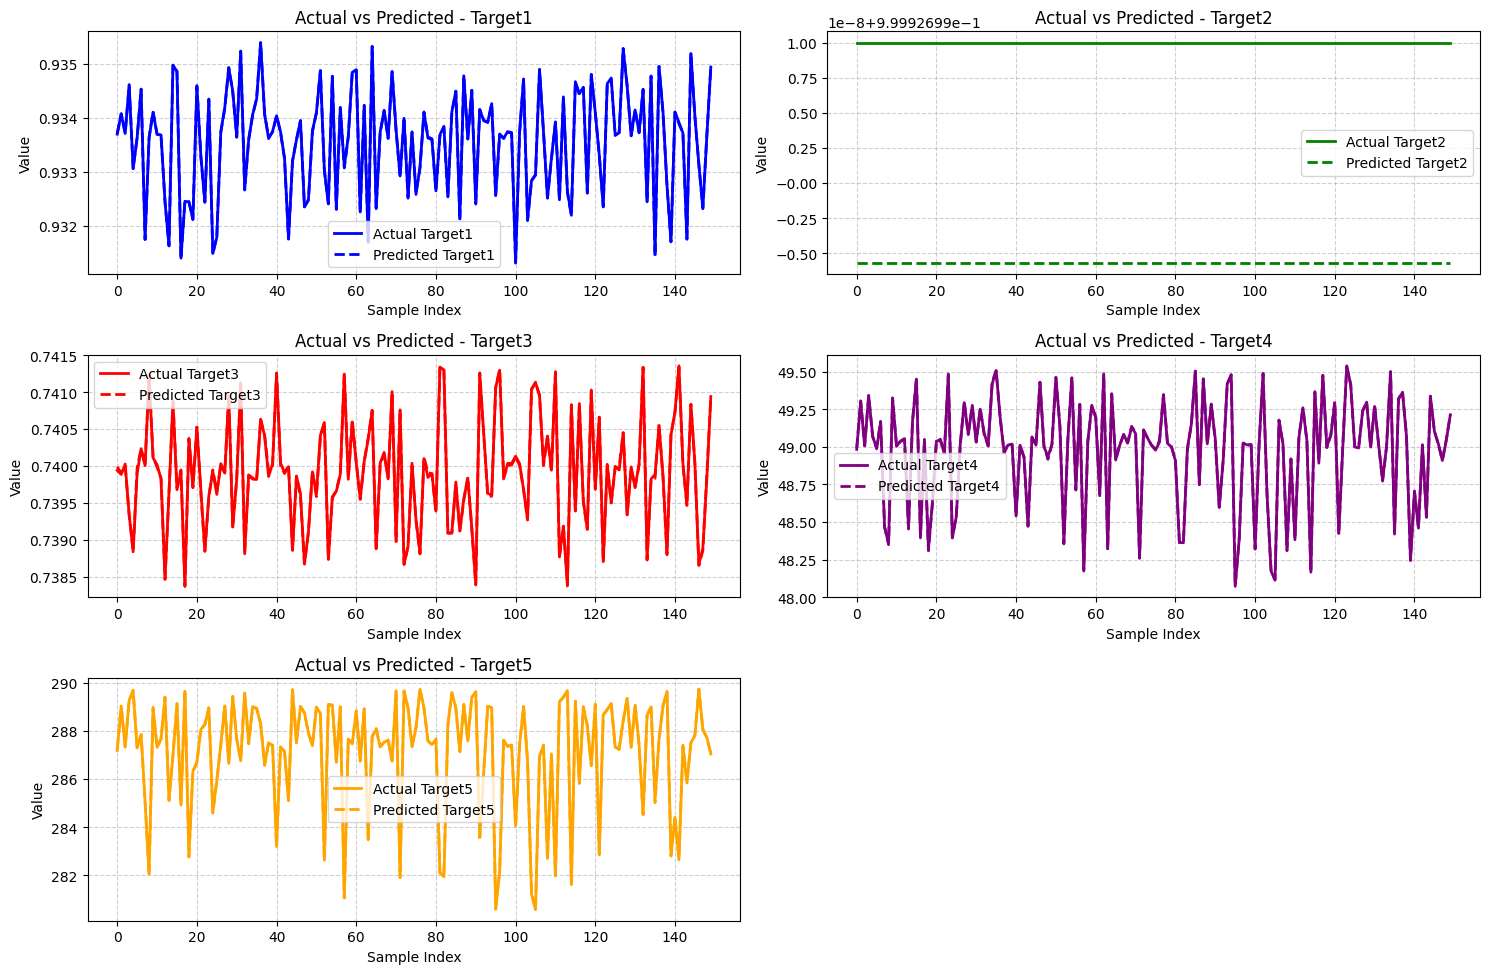

In [16]:
import matplotlib.pyplot as plt
import numpy as np

num_samples = min(150, y_test_inv.shape[0])  # تعداد نمونه برای رسم

targets = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# رنگ‌های متفاوت برای هر هدف
colors = ['blue', 'green', 'red', 'purple', 'orange']

plt.figure(figsize=(15, 10))

for i, (target, color) in enumerate(zip(targets, colors), start=1):
    plt.subplot(3, 2, i)
    plt.plot(y_test_inv[:num_samples, i-1], label=f'Actual {target}', color=color, linewidth=2)
    plt.plot(y_pred_inv[:num_samples, i-1], label=f'Predicted {target}', color=color, linestyle='--', linewidth=2)
    plt.title(f'Actual vs Predicted - {target}')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()